### t-SNE
- 비선형 차원 축소 기법으로 고차원의 데이터를 국소 구조를 보존하면서 2차원 또는 3차원 시각화를 하기 위해 사용
- 고차원 데이터의 경우에는 거리 기반 유사도 (가우시안 분포를 이용한 계산)
- 저차원의 경우에는 확률적으로 비슷하게 재현 (t-분포를 이용한 계산)
    - t-분포를 사용하는 이유는 멀리 떨어진 점간의 차이를 완화시키기 위한 방법

- 거리 계산 방법
    - 유클리드 거리(euclidean) : 기본적인 거리 계산 방식 (직선의 거리) -> 수치형 데이터에서 사용
    - 맨해튼 거리(manhatten) : 직각 축 기반 거리
    - 쳬비셰프 거리(chebyshev) : 최대의 축 차이 기반 거리
    - 코사인 거리(유사도)(cosine) : 벡터 방항 기반 거리 -> 자연어 데이터에서 사용
    - 마할라노비스 거리(mahalanobis) : 변수 간의 상관 반영
- parameter
    - n_components
        - 기본값 : 2
        - 축소할 차원의 개수
    - perplexity
        - 기본값 : 30
        - 이웃의 수 제어 (군집 크기에 민감)
        - 보통 5 ~ 50 정도의 값을 사용
        - 값이 작은 경우 작은 구조, 큰 경우 전체의 구조
        - 일반적으로 샘플의 개수 / 3
        - 너무 큰 값을 설정하면 전체를 포함하는 형태가 될 수 있다.
    - early_exggerarion
        - 기본값 : 12
        - 초기 학습에서 군집 간의 거리를 지정 (분리 촉진)
    - learning_rate
        - 기본값 : 'auto'
        - 학습의 속도
        - 너무 작게 지정하면 수렴이 느려짐
        - 너무 크게 지정하면 군집이 왜곡됨
        - 100 ~ 1000 정도의 값을 사용
    - max_iter
        - 기본값 : 1000
        - 전체 학습의 반복 횟수
    - n_iter_without_progress
        - 기본값 : 300
        - 개선이 없을 때 조기 종료의 기준
    - metric
        - 기본값 : 'euclidean'
        - 거리 계산 방식
- 속성
    - embedding_
        - 변환된 저차원 데이터를 반환
    - kl_divergence_
        - 최종 KL 발산 값을 반환 (작을수록 원래의 구조와 유사)
- 메서드
    - fit()
        - 데이터를 학습
    - transform()
        - 데이터를 저차원으로 변환

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
#digits 데이터를 로드
digits=load_digits()

In [3]:
len(digits.feature_names)

64

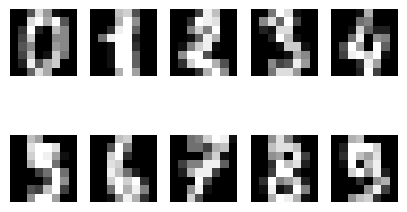

In [4]:
plt.figure(figsize=(5,3))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i],cmap='gray')
    # plt.title('label : ', digits.target[i])
    plt.axis('off')

plt.show()

In [5]:
import pandas as pd

In [6]:
pd.DataFrame(digits.data)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [7]:
#64차원의 데이터를 2차원으로 변경
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42,
    n_jobs=-1
)


In [8]:
x = StandardScaler().fit_transform(digits['data'])
y = digits['target']

In [9]:
x_tsne = tsne.fit_transform(x)

In [10]:
print(x.shape)
print(x_tsne.shape)

(1797, 64)
(1797, 2)


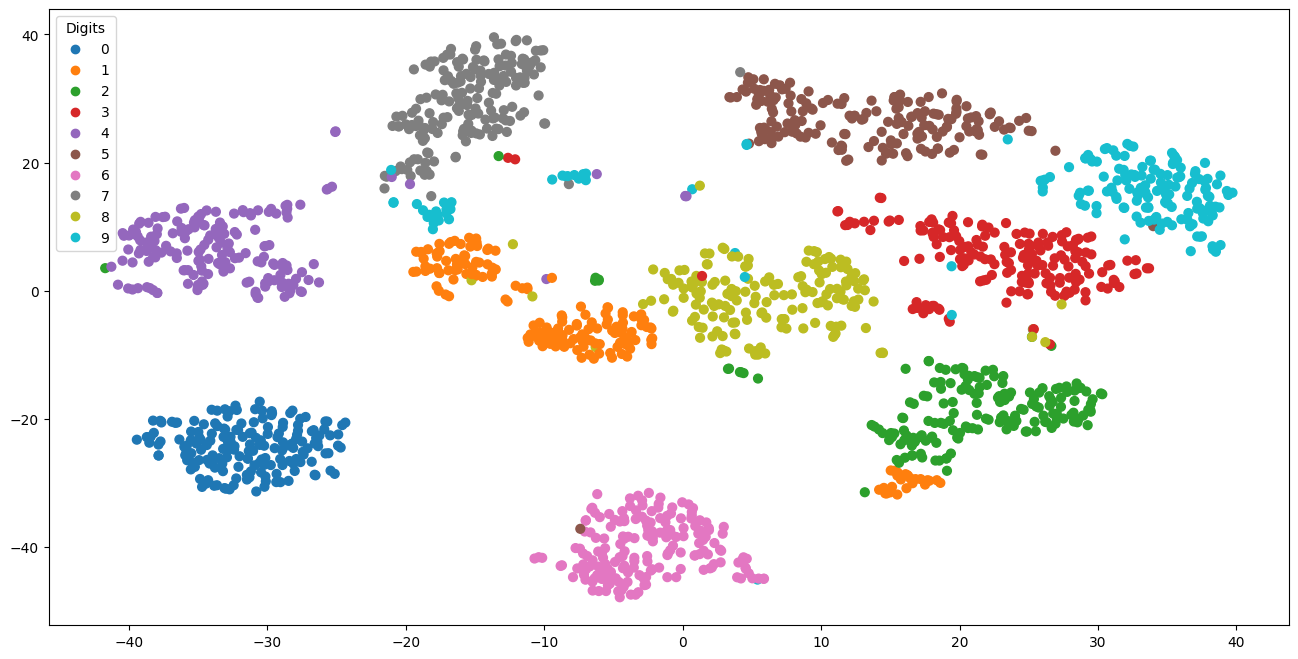

In [11]:
#2차원으로 축소된  데이터를 산점도 그래프로 표시
plt.figure(figsize=(16,8))

sc=plt.scatter(
    x_tsne[:,0],x_tsne[:,1],c=y, cmap='tab10',s=40
)

plt.legend(*sc.legend_elements(),title='Digits')
plt.show()

In [12]:
from sklearn.decomposition import PCA

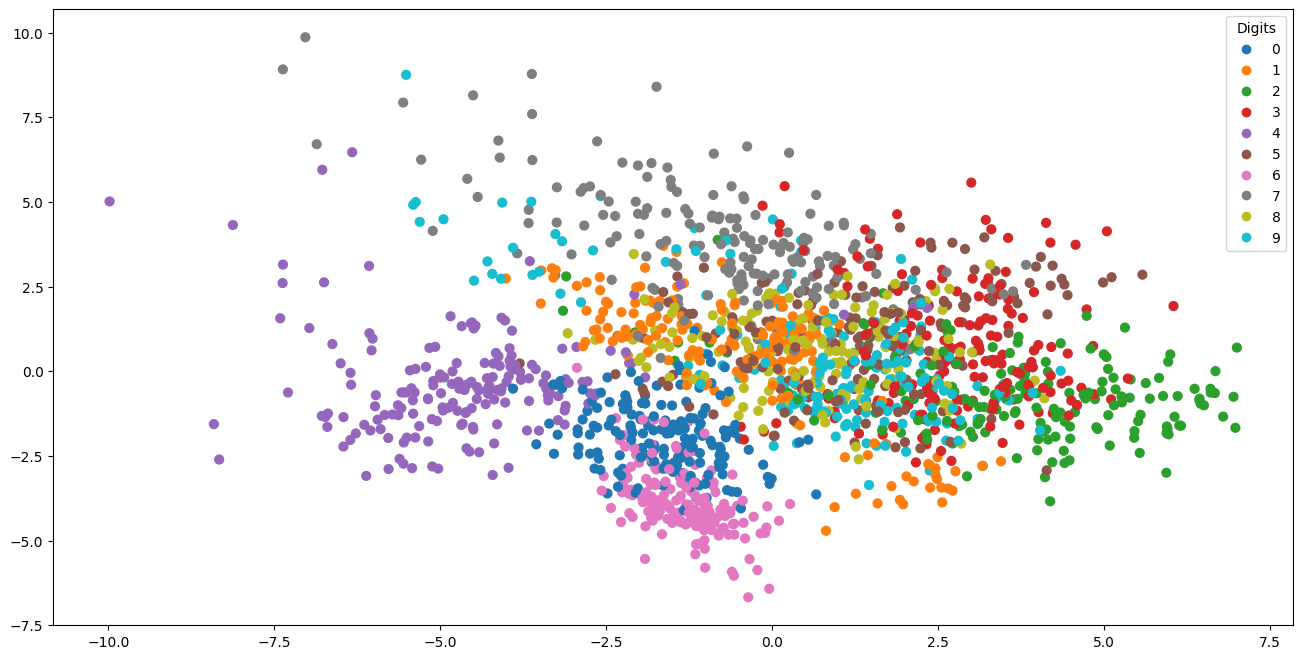

In [13]:
pca =PCA(n_components=2, random_state= 42)
x_pca=pca.fit_transform(x)

plt.figure(figsize=(16,8))

plt.scatter(
    x_pca[:,0],x_pca[:,1],c=y, cmap='tab10',s=40
)

plt.legend(*sc.legend_elements(),title='Digits')
plt.show()

In [14]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [15]:
#데이터를 생성 (10차원 3개 군집 데이터를 생성)
x, y = make_blobs(n_samples=600, centers=3, n_features=10, cluster_std=1.5, random_state=42)
#Scaler를 이용하야 스케일링
x_std=StandardScaler().fit_transform(x)

pd.DataFrame(x)

,0,1,2,3,4,5,6,7,8,9
0,-2.391245,6.016985,6.014370,2.492902,-5.382612,-11.224493,-5.705766,7.114138,3.684574,2.601593
1,-2.489695,11.194587,4.242894,6.053423,-5.941126,-8.165846,-10.444667,8.047232,1.687106,5.232452
2,3.021893,-9.040604,-7.183115,-6.921252,0.342371,5.896445,-6.345009,2.368225,2.804278,-6.646542
3,-11.537682,10.642796,7.865948,-7.475613,-5.135334,-4.025012,-5.598972,-0.881126,0.165393,-3.768174
4,1.481703,-7.436044,-5.306288,-4.364857,-0.413758,3.793141,-6.628465,-1.208072,2.672816,-6.368847
...,...,...,...,...,...,...,...,...,...,...
595,5.290868,-6.506656,-4.895042,-0.680678,-2.337747,6.313452,-6.265468,1.242704,1.752931,-11.247384
596,2.445026,-8.839312,-5.459498,-2.526043,0.777300,5.319098,-6.360399,-0.325639,1.046156,-8.628535
597,-4.529887,7.556865,6.440500,0.987828,-8.449994,-6.075130,-7.059772,8.401953,3.516372,3.026259
598,2.506491,-5.192401,-3.617499,-3.420714,-2.305377,5.190786,-7.516915,0.356427,1.001997,-11.312048


In [16]:
tsne=TSNE(n_components=2, perplexity=40, learning_rate=250, max_iter=1000, random_state=42)
x_tsne=tsne.fit_transform(x_std)

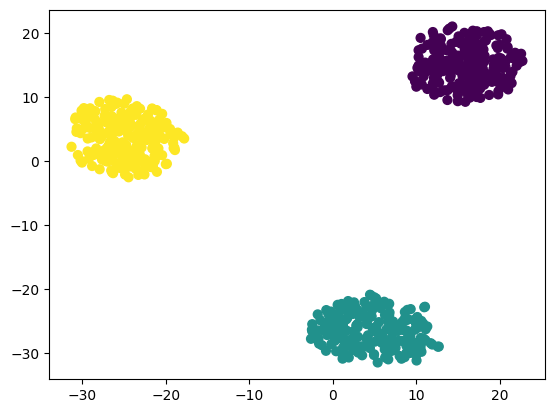

In [17]:
plt.scatter(x_tsne[:,0], x_tsne[:,1], c=y, cmap='viridis', s=40)
plt.show()

In [22]:
# body data를 tsne로 차원 축소 
df = pd.read_csv("../../data/bodyPerformance.csv")
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
obj_col=df.select_dtypes('object')
le=LabelEncoder()

for col in obj_col:
    df[col] = le.fit_transform(df[col])

In [25]:
#독립 /종속 나눠주기
x=df.drop(['gender','class'],axis=1)
y1=df['class']
y2=df['gender']

In [26]:
#x 데이터를 스케일링
x_std=StandardScaler().fit_transform(x)

In [27]:
x_std

array([[-0.71743212,  0.44387298,  0.65215002, ...,  0.37731734,
         1.41696147,  0.67400862],
       [-0.8642197 , -0.42246548, -0.97473438, ...,  0.12898358,
         0.92663372,  0.97501314],
       [-0.42385695,  1.31021144,  0.88312744, ..., -0.37950936,
         0.64644644, -0.22900492],
       ...,
       [ 0.16329338,  1.02538783,  1.09234611, ...,  0.14080899,
         0.36625915,  0.97501314],
       [ 1.99813815, -2.66545136, -0.81572819, ..., -0.71062104,
        -2.7858478 , -2.88787813],
       [-0.20367558, -0.54114198, -0.11275345, ..., -0.9589548 ,
         0.78654008, -0.25408863]], shape=(13393, 10))

In [28]:
tsne=TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    random_state=42
)

In [29]:
x_tsne=tsne.fit_transform(x_std)

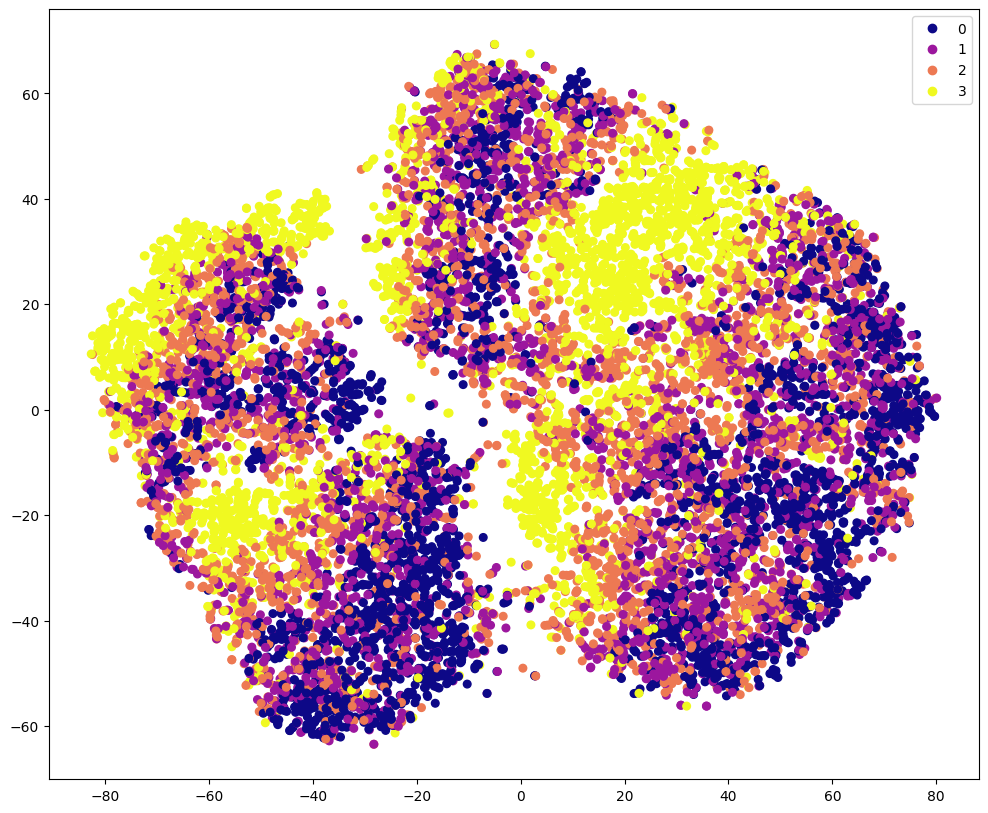

In [30]:
plt.figure(figsize=(12,10))

sc=plt.scatter(
    x_tsne[:,0],x_tsne[:,1], c=y1, cmap='plasma', s=30
)

plt.legend(*sc.legend_elements())

plt.show()

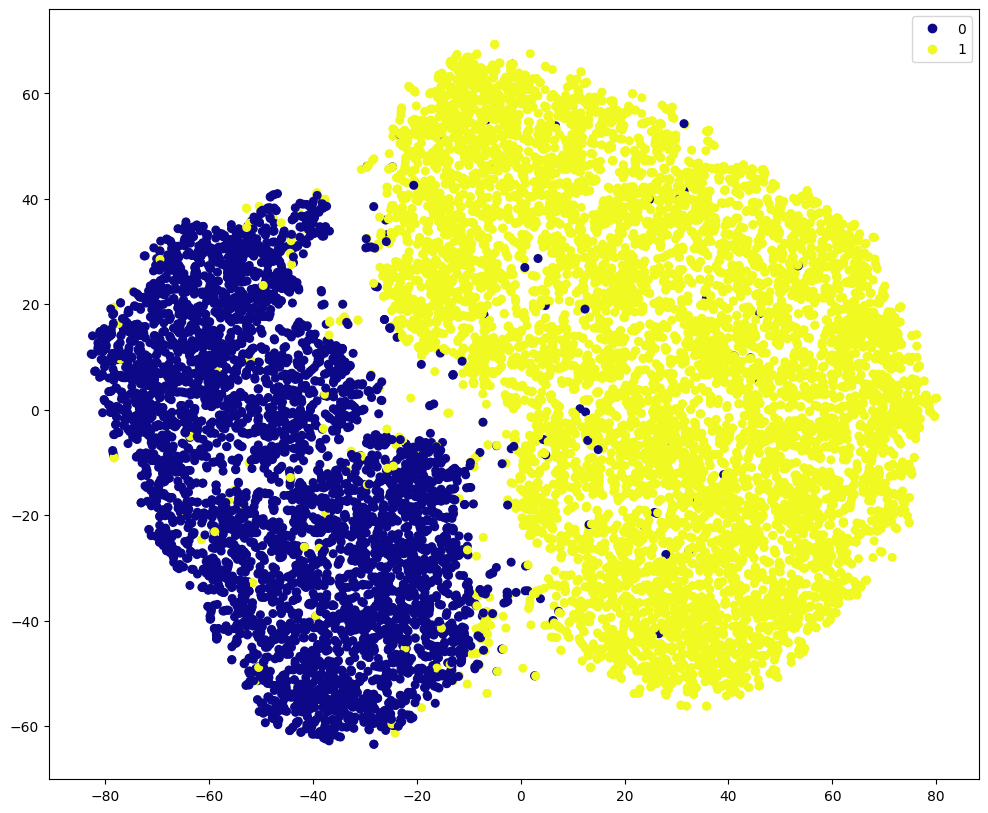

In [31]:
plt.figure(figsize=(12,10))

sc=plt.scatter(
    x_tsne[:,0],x_tsne[:,1], c=y2, cmap='plasma', s=30
)

plt.legend(*sc.legend_elements())

plt.show()

In [32]:
#결과 확인 -> kl_divergence_ : 고차원과 저차원 확률 분포의 차이 (작을 수록 좋음)
tsne.kl_divergence_

2.4155664443969727